In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

## 1. Load MNIST dataset

In [ ]:
## 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [ ]:
# 2. Normalize (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:

# 3. Reshape for CNN (Add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
#Pading to 32x32
x_train=tf.pad(x_train,[[0,0],[2,2],[2,2],[0,0]])
x_test=tf.pad(x_test,[[0,0],[2,2],[2,2],[0,0]])


In [ ]:
# # 4. Build CNN Model
# model = models.Sequential([

#     layers.Conv2D(6, (5,5), activation='tanh', input_shape=(32,232,1)),
#     layers.AveragePooling2D(pool_size=(2,2)),

#     layers.Conv2D(16, (5,5), activation='tanh'),
#     layers.AveragePooling2D(pool_size=(2,2)),

#     layers.Flatten(),

#     layers.Dense(120, activation='tanh'),
#     layers.Dense(84, activation='tanh'),

#     layers.Dense(10, activation='softmax')
# ])

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(32,32,1)),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(120, activation='tanh'),
    tf.keras.layers.Dense(84, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 6. Model Summary
model.summary()

# 7. Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_2                  │ (None, 14, 14, 6)           │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_3                  │ (None, 5, 5, 16)            │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9178 - loss: 0.2811 - val_accuracy: 0.9728 - val_loss: 0.1031
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9673 - loss: 0.1059 - val_accuracy: 0.9805 - val_loss: 0.0707
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9790 - loss: 0.0680 - val_accuracy: 0.9795 - val_loss: 0.0652
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9846 - loss: 0.0505 - val_accuracy: 0.9858 - val_loss: 0.0528
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.9855 - val_loss: 0.0489


In [ ]:

# 8. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0471 

Test Accuracy: 0.9843999743461609


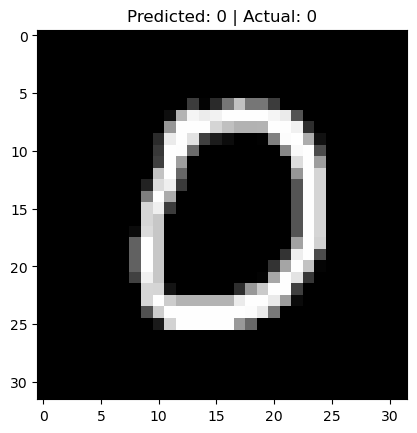

In [ ]:
plt.imshow(x_test[10].numpy().reshape(32,32), cmap='gray')
plt.title(f"Predicted: {predictions[10].argmax()} | Actual: {y_test[10]}")
plt.show()

In [ ]:
import numpy as np
y_pred_class=np.argmax(predictions,axis=1)


In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_class)
print(cm)

[[ 977    0    0    0    0    0    2    1    0    0]
 [   0 1131    1    2    0    0    0    0    0    1]
 [   4    2 1023    0    0    0    0    2    1    0]
 [   1    0    2  999    0    4    0    0    3    1]
 [   0    0    0    1  975    0    1    0    0    5]
 [   3    0    0   11    0  868    1    1    2    6]
 [   6    2    0    0    2    1  946    0    1    0]
 [   0    5    4    3    2    0    0  993    2   19]
 [   3    0    0    0    0    0    0    0  965    6]
 [   2    0    0    1    4    4    1    0    0  997]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.97      0.98       892
           6       0.99      0.99      0.99       958
           7       1.00      0.97      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.96      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

